In [7]:
import numpy as np
import tarfile
import os
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [8]:
np.random.seed(42)

### Učitavanje podataka

In [9]:
if not os.path.exists('data/jpg/'):
    with tarfile.open('data/102flowers.tgz', 'r:gz') as tar:
        tar.extractall(path='data/')

In [10]:
IMG_DIR = Path('data/jpg')
labels_raw = scipy.io.loadmat('data/imagelabels.mat')['labels'].flatten()

In [11]:
image_paths = sorted(IMG_DIR.glob('*.jpg'), key=lambda p: int(p.stem.split('_')[1]))

print(f"Total images: {len(image_paths)}")
print(f"Total labels: {len(labels_raw)}")
print(f"Label range: {labels_raw.min()} - {labels_raw.max()}  ({len(np.unique(labels_raw))} unique classes)")

Total images: 8189
Total labels: 8189
Label range: 1 - 102  (102 unique classes)


In [12]:
df = pd.DataFrame({
    'path': image_paths,
    'label': labels_raw
})
df.head()

,path,label
0,data/jpg/image_00001.jpg,77
1,data/jpg/image_00002.jpg,77
2,data/jpg/image_00003.jpg,77
3,data/jpg/image_00004.jpg,77
4,data/jpg/image_00005.jpg,77


### Analiza podataka

In [13]:
class_counts = df['label'].value_counts().sort_index()
median = class_counts.median()
mean = class_counts.mean()

print(f"Min samples per class: {class_counts.min()} (class {class_counts.idxmin()})")
print(f"Max samples per class: {class_counts.max()} (class {class_counts.idxmax()})")
print(f"Mean: {mean:.1f}")
print(f"Std: {class_counts.std():.1f}")
print(f"Median: {median:.0f}")

Min samples per class: 40 (class 1)
Max samples per class: 258 (class 51)
Mean: 80.3
Std: 44.3
Median: 66


In [14]:
below_median = class_counts[class_counts < int(median)]
over_median  = class_counts[class_counts > int(median)]
print(f"Number of classes over median: {len(over_median)}")
print(f"Number of classes below median: {len(below_median)}")

Number of classes over median: 49
Number of classes below median: 50


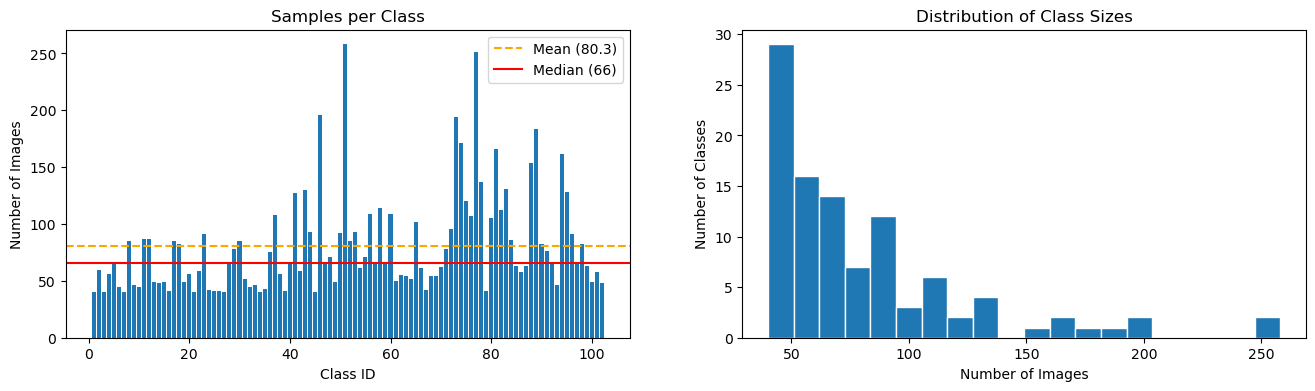

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 4))

ax1.bar(class_counts.index, class_counts.values)
ax1.axhline(class_counts.mean(), color  = "orange", linestyle="--", label = f'Mean ({class_counts.mean():.1f})')
ax1.axhline(class_counts.median(), color = "red", label = f'Median ({class_counts.median():.0f})')
ax1.set_xlabel('Class ID')
ax1.set_ylabel('Number of Images')
ax1.set_title('Samples per Class')
ax1.legend()

ax2.hist(class_counts.values, bins = 20, edgecolor = 'white')
ax2.set_xlabel('Number of Images')
ax2.set_ylabel('Number of Classes')
ax2.set_title('Distribution of Class Sizes')

plt.show()

In [16]:
img_info = []
for p in image_paths:
    try:
        with Image.open(p) as img:
            w, h = img.size
            mode = img.mode
        file_size = os.path.getsize(p)
        img_info.append({'path': p, 'width': w, 'height': h, 'mode': mode, 'file_size': file_size, 'corrupt': False})
    except (UnidentifiedImageError, OSError):
        img_info.append({'path': p, 'width': None, 'height': None, 'mode': None, 'file_size': None, 'corrupt': True})

img_info = pd.DataFrame(img_info)
df = df.merge(img_info.drop(columns=['path']), left_index=True, right_index=True)
df.head()

,path,label,width,height,mode,file_size,corrupt
0,data/jpg/image_00001.jpg,77,591,500,RGB,49057,False
1,data/jpg/image_00002.jpg,77,625,500,RGB,57207,False
2,data/jpg/image_00003.jpg,77,500,667,RGB,57837,False
3,data/jpg/image_00004.jpg,77,667,500,RGB,56469,False
4,data/jpg/image_00005.jpg,77,508,500,RGB,52293,False


Number of valid images: 8189
Width:  min: 500, max: 1024, mean: 630, std: 96
Height: min: 500, max: 1168, mean: 534, std: 75
Color modes  : {'RGB': 8189}


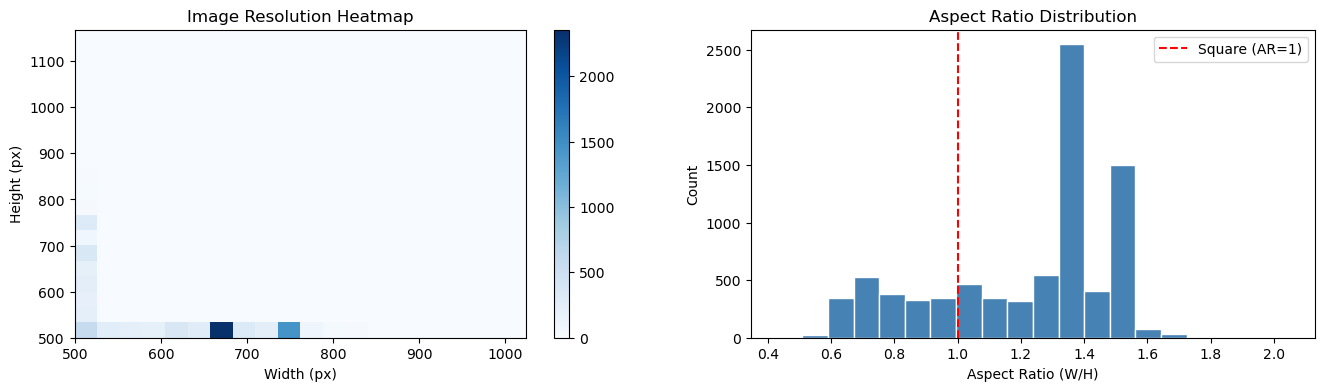

In [17]:
valid = df[~df['corrupt']]
print(f"Number of valid images: {len(valid)}")
print(f"Width:  min: {valid['width'].min()}, max: {valid['width'].max()}, "
      f"mean: {valid['width'].mean():.0f}, std: {valid['width'].std():.0f}")
print(f"Height: min: {valid['height'].min()}, max: {valid['height'].max()}, "
      f"mean: {valid['height'].mean():.0f}, std: {valid['height'].std():.0f}")
print(f"Color modes  : {valid['mode'].value_counts().to_dict()}")

valid = valid.copy()
valid['aspect_ratio'] = valid['width'] / valid['height']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.hist2d(valid['width'], valid['height'], bins=20, cmap='Blues')
ax1.set_xlabel('Width (px)'); ax1.set_ylabel('Height (px)')
ax1.set_title('Image Resolution Heatmap')
plt.colorbar(ax1.collections[0], ax=ax1)

ax2.hist(valid['aspect_ratio'], bins=20, color='steelblue', edgecolor='white')
ax2.axvline(1.0, color='red', linestyle='--', label='Square (AR=1)')
ax2.set_xlabel('Aspect Ratio (W/H)'); ax2.set_ylabel('Count')
ax2.set_title('Aspect Ratio Distribution')
ax2.legend()

plt.show()


In [18]:
corrupt_df = df[df['corrupt'] == True]
print(f"Corrupt images : {len(corrupt_df)}")

tiny_threshold_kb = 2.0
tiny = df[(~df['corrupt']) & (df['file_size'] < tiny_threshold_kb * 1024)]
print(f"Very small files (< {tiny_threshold_kb} kB): {len(tiny)}")

non_rgb = df[(~df['corrupt']) & (df['mode'] != 'RGB')]
print(f"Non-RGB images: {len(non_rgb)}")


Corrupt images : 0
Very small files (< 2.0 kB): 0
Non-RGB images: 0


In [19]:
if(len(corrupt_df) > 0):
    df.drop(corrupt_df.index, inplace=True)

print("Number of images after deleting corrupted: ", len(df))

Number of images after deleting corrupted:  8189


In [20]:
class_ids = np.random.choice(np.unique(df['label'].values), size=20, replace=False)
class_ids.sort()

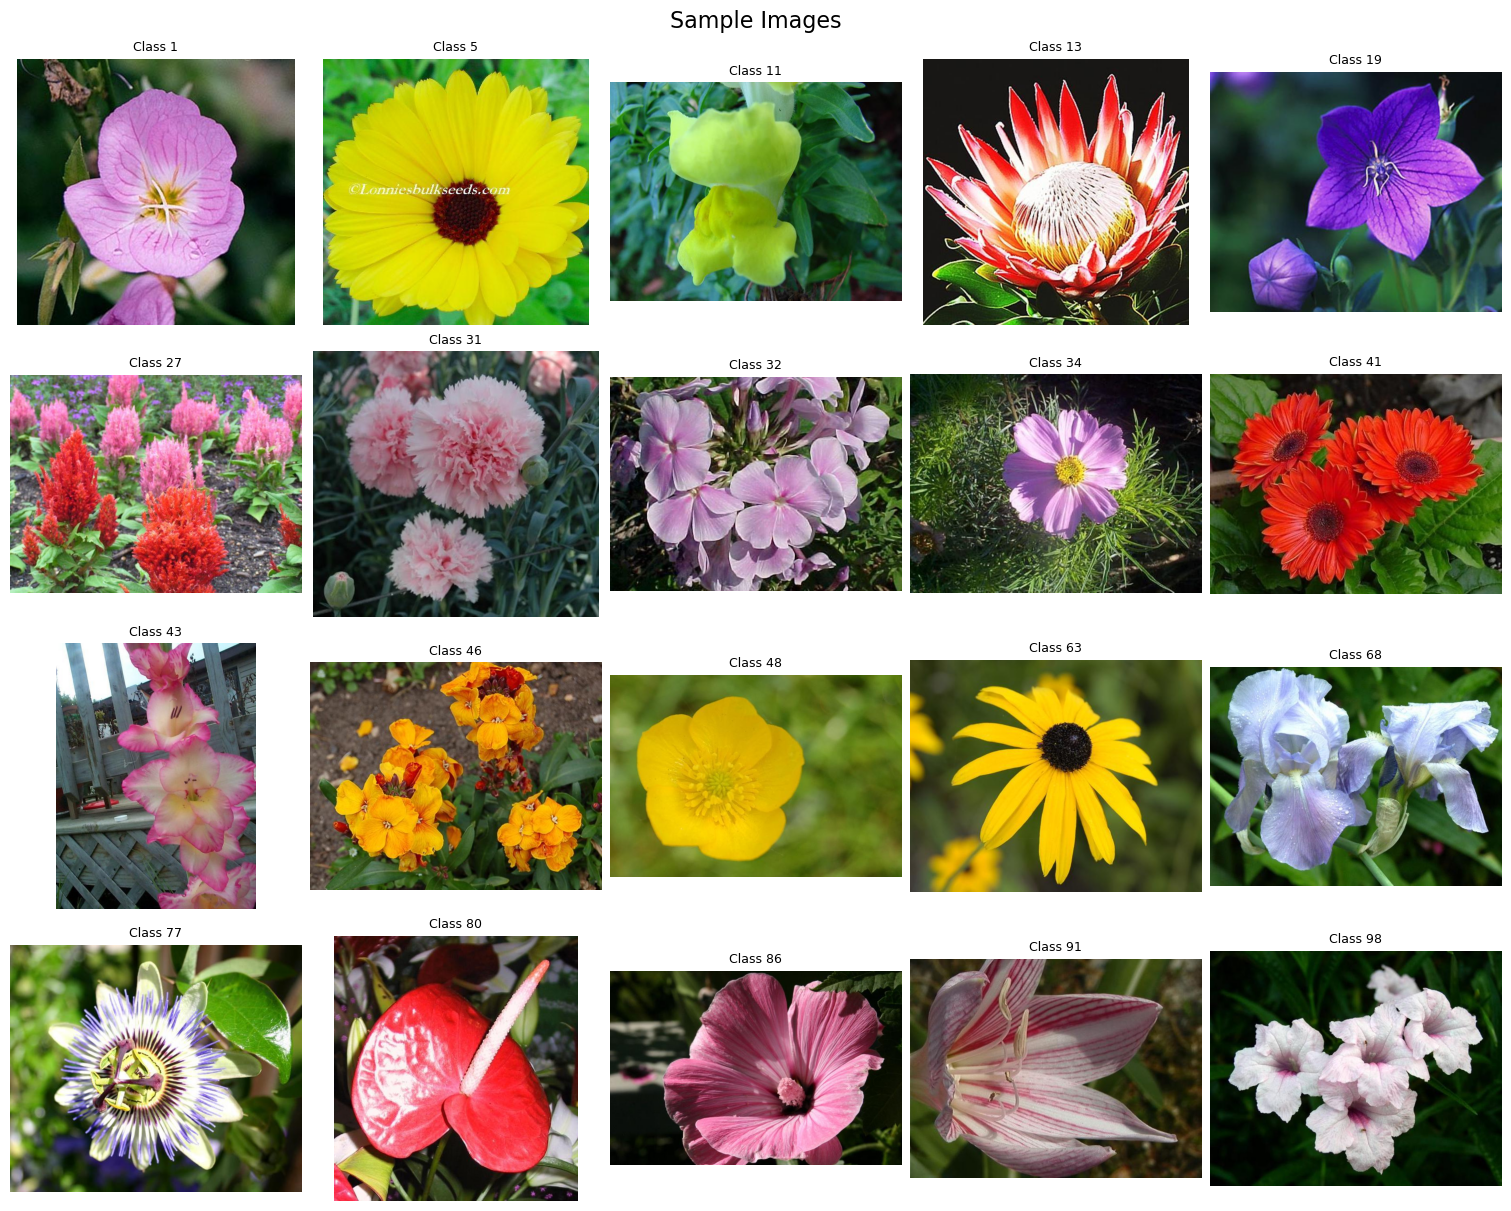

In [21]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for ax, id in zip(axes, class_ids):
    sample_path = df[df['label'] == id]['path'].iloc[0]
    img = Image.open(sample_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'Class {id}', fontsize=9)
    ax.axis('off')

fig.suptitle('Sample Images', fontsize=16)
fig.set_layout_engine('constrained')
plt.show()

In [22]:
channel_stats = []
for id in np.unique(df['label'].values):
    rows = df[df['label'] == id].sample(5, random_state=42)
    pixels = []
    for p in rows['path']:
        arr = np.array(Image.open(p).convert('RGB').resize((64, 64))) / 255.0
        pixels.append(arr.reshape(-1, 3))
    if pixels:
        pix = np.vstack(pixels)
        channel_stats.append({'class': id,
                               'mean_R': pix[:, 0].mean(), 'mean_G': pix[:, 1].mean(), 'mean_B': pix[:, 2].mean(),
                               'std_R':  pix[:, 0].std(),  'std_G':  pix[:, 1].std(),  'std_B':  pix[:, 2].std()})

stats_df = pd.DataFrame(channel_stats)

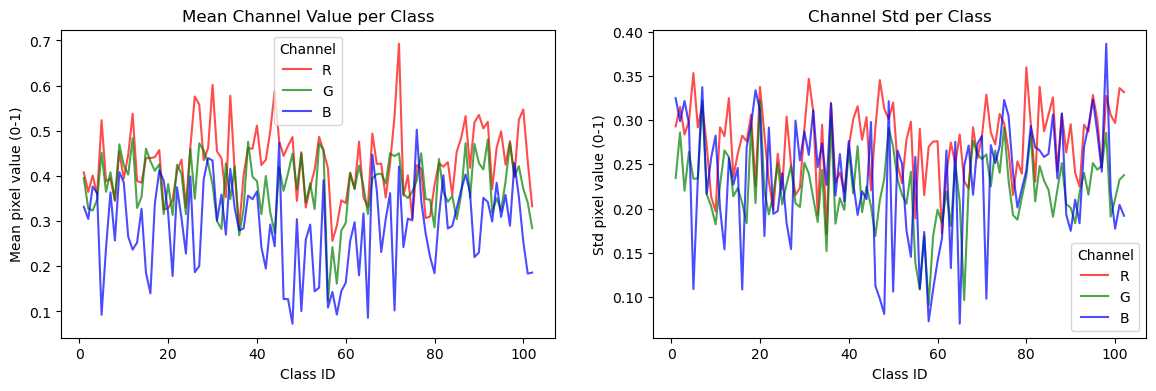

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ch, color in zip(['R', 'G', 'B'], ['red', 'green', 'blue']):
    axes[0].plot(stats_df['class'], stats_df[f'mean_{ch}'], color=color, alpha=0.7, label=ch)
axes[0].set_xlabel('Class ID'); axes[0].set_ylabel('Mean pixel value (0-1)')
axes[0].set_title('Mean Channel Value per Class')
axes[0].legend(title='Channel')

for ch, color in zip(['R', 'G', 'B'], ['red', 'green', 'blue']):
    axes[1].plot(stats_df['class'], stats_df[f'std_{ch}'], color=color, alpha=0.7, label=ch)
axes[1].set_xlabel('Class ID'); axes[1].set_ylabel('Std pixel value (0-1)')
axes[1].set_title('Channel Std per Class')
axes[1].legend(title='Channel')

plt.show()

Na grafu srednjih vrednosti pojedinačnih RGB kanala (vrednosti su dobijene na osnovu 5 primeraka iz svake klase) vidimo da je crvena dominantna boja u svim klasama, što ima smisla kada je u pitanju cveće - latice su pretežno toplih boja (crvene, ružičaste, žute, narandžaste i sl.). Zelena je uglavnom stabilna što odgovara činjenici da vaćina slika sadrži zelenu pozadinu, nevezano za boju cveta. Plava je najmanje zastupljena što je u skladu sa prethodna dva zapažanja. 

Boje značajno variraju među klasama, te procenjujemo da nose i značajnu informaciju u prepoznavanju klase.

Desni grafik se odnosi na standardnu devijaciju boja. NA nivou klasa varijacija boja je prilcno visoka, tj. slike sadrže raznovrsne intenzitete boja,a crvena boja ponovo ima najveće vrednosti. Kod nekih klasa primećuje se niska devijacija za određene kanale (primarno plavi i zeleni) što ukazuje na vizuelnu homogenost, tj. uniformnost boja, te će se možda ove klase pokazati lakšim za klasifikaciju.

### Preprocesiranje

In [24]:
IMG_SIZE   = (128, 128)   # (H, W) — change to 224 for pretrained CNN backbones
PIXEL_MEAN = np.array([0.485, 0.456, 0.406])   # ImageNet stats (good starting point)
PIXEL_STD  = np.array([0.229, 0.224, 0.225])

In [25]:
def load_and_transform(path, size=IMG_SIZE):
    """Load a JPEG, resize to size, convert to RGB, return float32 array in [0,1]."""
    with Image.open(path) as img:
        img = img.convert('RGB').resize((size[1], size[0]), Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0

In [26]:
def normalize(arr, mean=PIXEL_MEAN, std=PIXEL_STD):
    """Channel-wise standardization."""
    return (arr - mean) / std

In [27]:
sample_arr = load_and_transform(df['path'].iloc[0])
print(f"Preprocessed array shape : {sample_arr.shape}  dtype: {sample_arr.dtype}")
print(f"Pixel range before norm  : [{sample_arr.min():.3f}, {sample_arr.max():.3f}]")
norm_arr = normalize(sample_arr)
print(f"Pixel range after norm   : [{norm_arr.min():.3f}, {norm_arr.max():.3f}]")

Preprocessed array shape : (128, 128, 3)  dtype: float32
Pixel range before norm  : [0.000, 1.000]
Pixel range after norm   : [-2.084, 2.640]


Sve slike transofrmišemo na veličinu određenu sa `IMG_SIZE`. Zatim se od nje pravi vektor vrednosti u rasponu [0.0, 1.0], nad kojim se vrši normalizacija na nivou RGB kanala koristeći srednje vrednosti iz `PIXEL_MEAN` i `PIXEL_STD`. Rezultati ove obrade date su na slici ispod. 

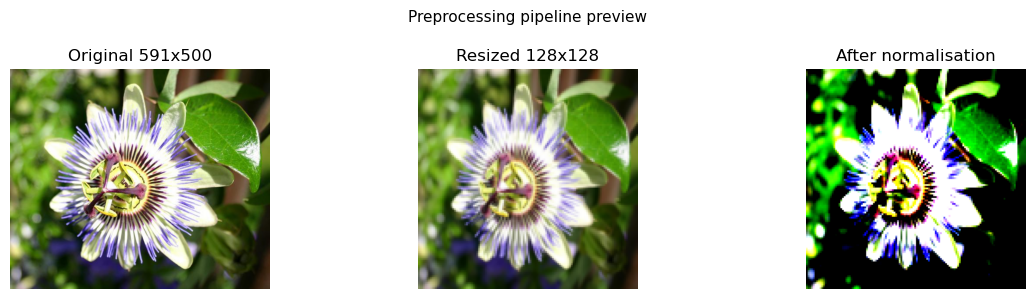

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
sample_path = df['path'].iloc[0]
orig = np.array(Image.open(sample_path).convert('RGB'))
resized = (sample_arr * 255).astype(np.uint8)

axes[0].imshow(orig)
axes[0].set_title(f'Original {orig.shape[1]}x{orig.shape[0]}')
axes[0].axis('off')

axes[1].imshow(resized)
axes[1].set_title(f'Resized {IMG_SIZE[1]}x{IMG_SIZE[0]}')
axes[1].axis('off')

axes[2].imshow(np.clip(norm_arr, 0, 1))
axes[2].set_title('After normalisation')
axes[2].axis('off')

plt.suptitle('Preprocessing pipeline preview', fontsize=11)
plt.tight_layout()
plt.show()

### Train/Validation/Test 

Skup podataka delimo na skup za treniranje, validaciju i testiranje u razmeri 70:15:15. Vrsena je i stratifikacija prema ciljnoj promenljivoj, tj. klasi za obezbedjivanje proporcionalne prisutnosti klasa u svakom skupu. 

In [29]:
X = df['path'].values
y = df['label'].values
idx = np.arange(len(df))

In [30]:
X_train_val, X_test, y_train_val, y_test, itr, ite = train_test_split(X, y, idx, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val, itr, iva = train_test_split(X_train_val, y_train_val, itr, test_size=0.15 / 0.85, stratify=y_train_val, random_state=42)

### Kernelizovani K Nearest Neighbors

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import rbf_kernel

In [32]:
KNN_IMG_SIZE = (64, 64)

#### [Kernel kao tezine](https://learningfromdata.netlify.app/pdfs/kknn/kknn_presentation.pdf)

Funkcija `rbf_weights` sluzi za racunanje tezina svakog suseda. Tezina je odredjena na osnovu RBF (Gausovog) kernela nad distancama:
$$ w_i = e^{-\gamma d_i^2} $$

Bliži susedi imaju veću težinu, a $\gamma$ određuje koliko "brzo" uticaj opada.

In [54]:
def rbf_weights(distances, gamma):
    return np.maximum(np.exp(-gamma * distances ** 2), 1e-12)

In [34]:
def build_feature_matrix(paths, size=KNN_IMG_SIZE):
    feats = np.empty((len(paths), size[0] * size[1] * 3), dtype=np.float32)
    for i, p in enumerate(paths):
        img = load_and_transform(p, size)
        feats[i] = img.ravel()
    return feats

In [35]:
X_train_feat = build_feature_matrix(X_train, size=KNN_IMG_SIZE)
X_val_feat = build_feature_matrix(X_val, size=KNN_IMG_SIZE)
X_test_feat = build_feature_matrix(X_test, size=KNN_IMG_SIZE)

In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled = scaler.transform(X_val_feat)
X_test_scaled = scaler.transform(X_test_feat)

In [37]:
# klasican model
knn_classic = KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1)
knn_classic.fit(X_train_scaled, y_train)

y_val_pred_classic = knn_classic.predict(X_val_scaled)
print("Validation accuracy for classic KNN (k = 5): ", accuracy_score(y_val, y_val_pred_classic))

Validation accuracy for classic KNN (k = 5):  0.14890154597233524


In [38]:
gamma = 1.0 / X_train_scaled.shape[1]  # 1 / broj atributa * varijansa (skup je normalizovan pa je varijansa 1)
knn_kernel = KNeighborsClassifier(n_neighbors=15, weights=lambda d: rbf_weights(d, gamma), n_jobs=-1)
knn_kernel.fit(X_train_scaled, y_train)

y_val_pred_kernel = knn_kernel.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_val_pred_kernel)
print("Validation accuracy for RBF KNN (k = 15): ", val_accuracy)

Validation accuracy for RBF KNN (k = 15):  0.14727420667209112


##### Hiperparametri k i $\gamma$ za kernelizovani KNN

In [55]:
k_values = [5, 11, 15, 21, 31, 51]
gamma_values = [0.0001, 0.001, 0.01, 0.1, 1, 10] 


In [56]:
results = []
for k in k_values:
    for g in gamma_values:
        model = KNeighborsClassifier(n_neighbors=k, weights=lambda d, g=g: rbf_weights(d, g), n_jobs=-1) # g=g uzima trenutnu vr g, a ne onu kada se pozove funkcija
        model.fit(X_train_scaled, y_train)

        acc = accuracy_score(y_val, model.predict(X_val_scaled))
        results.append({"k": k, "gamma": g, "acc": acc})
                       

In [57]:
best = results[np.argmax([r['acc'] for r in results])]
print("Best hyperparameters: ", best)

Best hyperparameters:  {'k': 5, 'gamma': 0.001, 'acc': 0.16273393002441008}


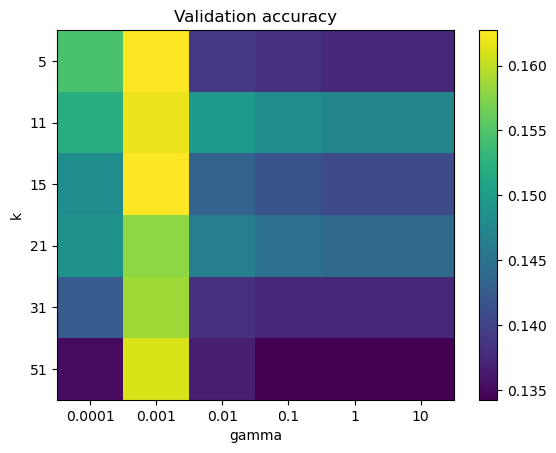

In [58]:
res_df = pd.DataFrame(results)
pivot = res_df.pivot(index = "k", columns = "gamma", values = "acc")

fig, ax = plt.subplots()
im = ax.imshow(pivot.values, aspect = "auto")

ax.set_xticks(range(len(pivot.columns))) 
ax.set_xticklabels([f'{g:g}' for g in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel("gamma")
ax.set_ylabel("k")
ax.set_title("Validation accuracy")
plt.colorbar(im, ax=ax)
plt.show()

In [59]:
final = KNeighborsClassifier(n_neighbors=best['k'], weights=lambda d: rbf_weights(d, best['gamma']), n_jobs=-1)
final.fit(X_train_scaled, y_train)

y_test_pred = final.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test accuracy: ", test_accuracy)
print(classification_report(y_test, y_test_pred, digits=4, zero_division=0))

Test accuracy:  0.16517493897477625
              precision    recall  f1-score   support

           1     0.0000    0.0000    0.0000         6
           2     0.3846    0.5556    0.4545         9
           3     0.0000    0.0000    0.0000         6
           4     0.1667    0.1250    0.1429         8
           5     0.2500    0.2000    0.2222        10
           6     0.0000    0.0000    0.0000         7
           7     0.0000    0.0000    0.0000         6
           8     1.0000    0.0769    0.1429        13
           9     0.0000    0.0000    0.0000         7
          10     0.1250    0.1429    0.1333         7
          11     0.0000    0.0000    0.0000        13
          12     0.1000    0.0769    0.0870        13
          13     0.2000    0.1429    0.1667         7
          14     0.1875    0.4286    0.2609         7
          15     1.0000    0.2857    0.4444         7
          16     0.1250    0.1667    0.1429         6
          17     0.5000    0.0769    0.1333  

#### Kernel kao rastojanje

[Rastojanje indukovano kernelom](https://arxiv.org/pdf/1103.1625) mozemo definsati kao:
$$ d(x, x') = sqrt(K(x,x) + K(x',x') - 2K(x,x')) = sqrt(2 - 2K(x,x'))$$
Za normalizovane kernele gde $K(x,x) = 1$ indukovano rastojanje je onda:
$$ d(x, x') = sqrt(2 - 2K(x,x'))$$

Koristicemo $\chi^2$ kernel, jer je njegovo "geometrijsko ponasanje" drugacije od Euklidskog rastojanja.
$$K(x,x') = e^{-\gamma \frac{(x - x')^2}{x + x'}} $$
Ovo ne vazi i za RBF:
$$ K(x, x') = e^{-\gamma ||x-x'||^2} $$
$||x-x'||^2$ je kvadratno Euklidsko rastojanje, te mozemo reci da je rastojanje indukovano RBF kernelom monotona funkcija nad Euklidskim rastojanjima. Dakle blizim tackama RBF kernel dodeljuje vecu slicnost. Zbog ovoga ce "nabrajanje" suseda biti identicno kao da smo koristili Euklidski KNN. 

In [60]:
from sklearn.metrics.pairwise import chi2_kernel
from sklearn.metrics.pairwise import additive_chi2_kernel

In [61]:
#chi2 zahteva nenegativne ulaze, koristiti vr piksela na skali [0,1] a ne sklairane StandardScalareom
def chi2_distance(A, B, gamma):
    K = chi2_kernel(A, B, gamma=gamma)
    return np.sqrt(np.maximum(0, 2.0 - 2.0 * K))  # samo nenegativne vrednosti jer koristimo metric="precomputed"

In [62]:
gamma = 1.0 / X_train_feat.shape[1]  # 1 / broj atributa * varijansa (skup je normalizovan pa je varijansa 1)
d_train = chi2_distance(X_train_feat, X_train_feat, gamma)
d_val = chi2_distance(X_val_feat, X_train_feat, gamma)

knn_chi2 = KNeighborsClassifier(n_neighbors=15, metric='precomputed', weights="distance", n_jobs=-1)
knn_chi2.fit(d_train, y_train)
print("Validation accuracy for Chi2 KNN (k = 15):", accuracy_score(y_val, knn_chi2.predict(d_val)))

Validation accuracy for Chi2 KNN (k = 15): 0.14564686737184704


#### Hiperparametri $\gamma$ i k

In [63]:
def chi2_dist_from_s(s, gamma):
    K = np.exp(gamma * s)
    return np.sqrt(np.maximum(0, 2.0 - 2.0 * K))

In [64]:
s_train = additive_chi2_kernel(X_train_feat, X_train_feat)
s_val = additive_chi2_kernel(X_val_feat, X_train_feat)

In [65]:
k_values = [5, 11, 15, 21, 31, 51]
gamma_values = [0.0001, 0.001, 0.01, 0.1, 1, 10] 

In [66]:
results_chi2 = []
for g in gamma_values:
    d_train = chi2_dist_from_s(s_train, g)
    d_val = chi2_dist_from_s(s_val, g)
    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k, metric='precomputed', weights="distance", n_jobs=-1)
        model.fit(d_train, y_train)
        acc = accuracy_score(y_val, model.predict(d_val))
        results_chi2.append({"k": k, "gamma": g, "acc": acc})

In [67]:
best = results_chi2[np.argmax([r['acc'] for r in results_chi2])]
print("Best hyperparameters: ", best)

Best hyperparameters:  {'k': 5, 'gamma': 0.0001, 'acc': 0.15215622457282343}


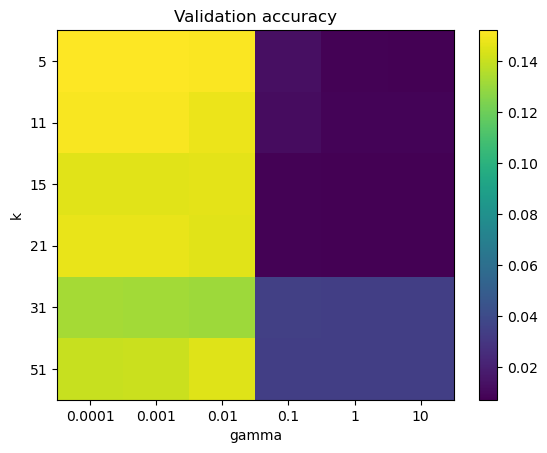

In [68]:
res_df = pd.DataFrame(results_chi2)
pivot = res_df.pivot(index = "k", columns = "gamma", values = "acc")

fig, ax = plt.subplots()
im = ax.imshow(pivot.values, aspect = "auto")

ax.set_xticks(range(len(pivot.columns))) 
ax.set_xticklabels([f'{g:g}' for g in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel("gamma")
ax.set_ylabel("k")
ax.set_title("Validation accuracy")
plt.colorbar(im, ax=ax)
plt.show()

### [HOG - Histogram orijentisanih gradijenata](https://www.kaggle.com/code/brendan45774/hog-features-histogram-of-oriented-gradients)

https://en.wikipedia.org/wiki/Histogram_of_oriented_gradients

In [69]:
from skimage.feature import hog

HOG_SIZE = (128, 128)

In [70]:
def hog_features(path, size=HOG_SIZE):
    with Image.open(path) as img:
        img = img.convert('RGB').resize((size[1], size[0]), Image.BILINEAR)
    gray = np.array(img.convert('L'), dtype=np.float32)
    return hog(gray, pixels_per_cell=(16, 16), cells_per_block=(2, 2), block_norm="L2-Hys", feature_vector=True) 

### [HSV izdvajanje atributa](https://iopscience.iop.org/article/10.1088/1742-6596/2017/1/012010/pdf)

In [71]:
from skimage.color import rgb2hsv

In [72]:
def hsv_hist(path, bins=(8, 8, 8), size=(128, 128)):
    with Image.open(path) as img:
        img = img.convert('RGB').resize((size[1], size[0]), Image.BILINEAR)
    hsv = rgb2hsv(np.array(img, dtype=np.float32) / 255.0)
    hist= np.histogramdd(hsv.reshape(-1, 3), bins=bins, range=((0, 1), (0, 1), (0, 1)))[0].ravel()
    return hist / (hist.sum() + 1e-6)  # L1 normalizacija

#### Matrica `Chi2` rastojanja na osnovu izdvojenih atributa

In [73]:
paths = df['path'].values
hog_all = np.stack([hog_features(p) for p in paths]).astype(np.float32)
hsv_all = np.stack([hsv_hist(p) for p in paths]).astype(np.float32)

print(hog_all.shape, hsv_all.shape)

(8189, 1764) (8189, 512)


In [74]:
def make_chi2_matrices(features_all, itr, iva, ite, gamma):
    features_tr, features_va, features_te = features_all[itr], features_all[iva], features_all[ite]
    D_tr = chi2_distance(features_tr, features_tr, gamma)
    D_va = chi2_distance(features_va, features_tr, gamma) 
    D_te = chi2_distance(features_te, features_tr, gamma)   
    return D_tr, D_va, D_te

In [76]:
def eval_precomputed(D_tr, D_va, y_tr, y_va, k = 15):
    model = KNeighborsClassifier(n_neighbors = k, metric = "precomputed", weights = "distance", n_jobs = -1)
    model.fit(D_tr, y_tr)
    y_va_pred = model.predict(D_va)
    acc = (y_va_pred == y_va).mean()
    return y_va_pred, acc

In [77]:
gamma_hog = 1.0 / hog_all.shape[1]
gamma_hsv = 1.0 / hsv_all.shape[1]

# D_hog_tr, D_hog_va, D_hog_te = make_chi2_matrices(hog_all, X_train.index, X_val.index, X_test.index, gamma_hog)
Dhog_tr, Dhog_va, Dhog_te = make_chi2_matrices(hog_all, itr, iva, ite, gamma_hog)
Dhsv_tr, Dhsv_va, Dhsv_te = make_chi2_matrices(hsv_all, itr, iva, ite, gamma_hsv)

In [78]:
# comb = 0.5D1 + 0.5D2 - podjednako ucestvuju -> restujemo ih tkd D_novo = D / D.mean() => D_novo.mean() = 1
def normalize_D(D):
    return D / (D.mean() + 1e-6)
Dcomb_tr = 0.5 * normalize_D(Dhog_tr) + 0.5 * normalize_D(Dhsv_tr)
Dcomb_va = 0.5 * normalize_D(Dhog_va) + 0.5 * normalize_D(Dhsv_va)

_, acc_comb = eval_precomputed(Dcomb_tr, Dcomb_va, y_train, y_val)
print("Validation accuracy for combined HOG + HSV KNN (k = 15): ", acc_comb)

Validation accuracy for combined HOG + HSV KNN (k = 15):  0.4019528071602929


In [79]:
weights = np.linspace(0, 1, 11)
results_comb = []

for w in weights:
    Dcomb_tr = w * normalize_D(Dhog_tr) + (1 - w) * normalize_D(Dhsv_tr)
    Dcomb_va = w * normalize_D(Dhog_va) + (1 - w) * normalize_D(Dhsv_va)
    _, acc = eval_precomputed(Dcomb_tr, Dcomb_va, y_train, y_val)
    results_comb.append({"weight": w, "acc": acc})

best_comb = results_comb[np.argmax([r['acc'] for r in results_comb])]
print("Best weight for HOG + HSV combination: ", best_comb)

Best weight for HOG + HSV combination:  {'weight': 0.2, 'acc': 0.42066720911310007}


In [80]:
w = best_comb["weight"]
Dcomb_tr = w * normalize_D(Dhog_tr) + (1 - w) * normalize_D(Dhsv_tr)
Dcomb_te = w * normalize_D(Dhog_te) + (1 - w) * normalize_D(Dhsv_te)

y_test_pred, test_acc = eval_precomputed(Dcomb_tr, Dcomb_te, y_train, y_test)
print("Test accuracy for combined HOG + HSV KNN (k = 15): ", test_acc)

Test accuracy for combined HOG + HSV KNN (k = 15):  0.43938161106590723
